<a href="https://colab.research.google.com/github/m-orozco/EE110L-Signals-Systems/blob/main/Lab_11_Fourier/EE110Lch11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

a0=0.500000000000000
an=sin(pi*n)/(pi*n)
bn=(-To*cos(pi*n)/(pi*n) + To/(pi*n))/To
The an constants are:
The bn constants are:
b1= 0.636942675159236
b3= 0.212314225053079
b5= 0.127388535031847
function= 0.636942675159236*sin(2*pi*t) + 0.212314225053079*sin(6*pi*t) + 0.127388535031847*sin(10*pi*t) + 0.5


/tmp/ipykernel_1082/860312514.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


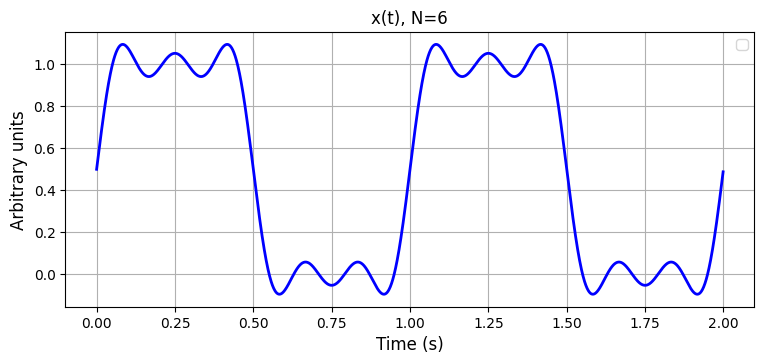

In [3]:
import sympy as sy
from sympy import *
from sympy.abc import x
import numpy as np
#Make the numpy methods available as plt.()
import matplotlib.pyplot as plt
init_printing(use_unicode=False, wrap_line=False, no_global=True)
t = symbols("t", positive=True)
To, duty,n = symbols(" To,duty,n ", positive=True)
def x(t):
    return pulse(t,0.5,To)
def pulse(x,duty,To):
    return Piecewise((0, x>=duty*To),(1,x>=0),(0,x<0))
def saw(x,duty,To):
    return Piecewise((0, x>=To),(x,x>=0),(0,x<0))
a0=integrate(x(t),(t,0,To))/To
print("a0={}".format(a0))

an=integrate(x(t)*cos(2*pi/To*t*n),(t,0,To))*2/To
bn=integrate(x(t)*sin(2*pi/To*t*n),(t,0,To))*2/To
print("an={}".format(an))
print("bn={}".format(bn))
freq=1.0
print("The an constants are:")
function=a0
N=6
for i in range(1,N):
    ai=an.subs(n,i).subs(To,1/freq).subs(pi,3.14)
    if abs(ai)>0:
        print("a{}=".format(i),ai)
        function=function+ai*cos(2*pi*i*freq*t)
print("The bn constants are:")
for i in range(1,N):
    bi=bn.subs(n,i).subs(To,1/freq).subs(pi,3.14)
    if abs(bi)>0:
        print("b{}=".format(i),bi)
        function=function+bi*sin(2*pi*i*freq*t)
print("function=",function)
evalfunc = lambdify((t), function, modules=['numpy'])
t = np.arange(0, 2/freq, 0.001)

fig, (ax2) = plt.subplots(1,figsize=(8,4))
[line3] = ax2.plot(t, evalfunc(t), linewidth=2, color='blue')
ax2.set_xlabel('Time (s)',fontsize=12)
ax2.set_ylabel('Arbitrary units',fontsize=12)
ax2.set_title('x(t), N={}'.format(N))
ax2.grid()
ax2.legend()
plt.tight_layout(pad=2, w_pad=2, h_pad=2.0)
plt.show()


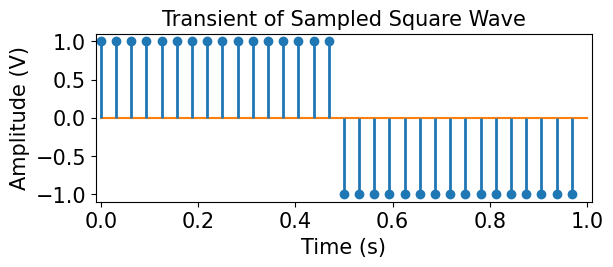

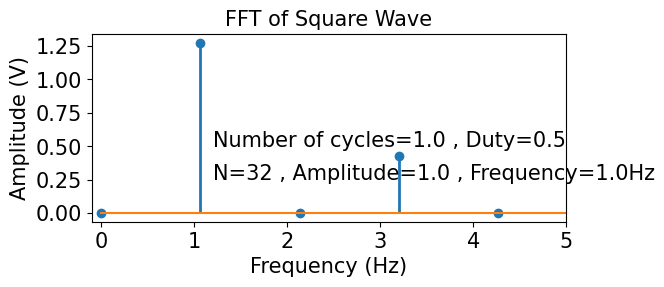

In [ ]:
from scipy.fftpack import fft
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
#Amplitude of the square wave
A=1.0
#Frequency in Hz of square wave
F=1.0
# Number of times the square wave is sampled
N = 2**5

#Number of periods to simulate
NC=1.

# Simulation time
T=NC/F
dT=T/N
#Create X-axis data
x = np.linspace(0.0, T, N,endpoint=False)
#Create sin wave data
D=.5
y=A*signal.square(2*np.pi*F*x,duty=D)
#Create  fake data so that an axis appears at 0
x2 = np.linspace(0.0, T, 2)
y2=x2*0
# Plot sin wave with a closed circle
plt.subplot(2, 1, 1,)
plt.plot(x, y , 'o')
#Place horizontal line at y=0
plt.plot(x2,y2)
#Plot vertical lines from the x-axis to the data point
plt.vlines(x, [0], y, lw=2)
#Titles and Labels
plt.ylabel('Amplitude (V)',fontsize=15)
plt.xlabel('Time (s)',fontsize=15)
plt.title('Transient of Sampled Square Wave',fontsize=15)
#Set limits to just a bit bigger than the data so that the circles do not get cut off.
plt.ylim(-1.1,1.1)
plt.xlim(-0.01,T+.01)
plt.yticks( size=15)
plt.xticks( size=15)
plt.show()
yf = fft(y)
xf = np.linspace(0.0, 1.0/(2.0*dT), int(N/2))
plt.subplot(2, 1, 2)
plt.title( 'FFT of Square Wave',fontsize=15)
#plt.plot(x,y)
yf[0]=yf[0]/2.
#plt.semilogx(xf, 2.0/N * np.abs(yf[0:N/2]), 'o', lw=2)
plt.plot(xf, 2.0/N * np.abs(yf[0:int(N/2)]), 'o', lw=2)
plt.vlines(xf, [0], 2.0/N * np.abs(yf[0:int(N/2)]), lw=2)
plt.plot(xf,xf*0)
plt.ylabel('Amplitude (V)',fontsize=15)
plt.xlabel('Frequency (Hz)',fontsize=15)
plt.yticks( size=15)
plt.xticks( size=15)
plt.xlim(-.1,5)
plt.text(1.2, .5, 'Number of cycles='+repr(NC)+' , Duty='+repr(D),fontsize=15)
plt.text(1.2, .25, 'N='+repr(N)+' , Amplitude='+repr(A)+' , Frequency='+repr(F)+'Hz',fontsize=15)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.show()

a0=0.500000000000000
an=sin(pi*n)/(pi*n)
bn=(-To*cos(pi*n)/(pi*n) + To/(pi*n))/To
The an constants are:
The bn constants are:
b1= 0.636942675159236
b3= 0.212314225053079
function= 0.636942675159236*sin(2000*pi*t) + 0.212314225053079*sin(6000*pi*t) + 0.5


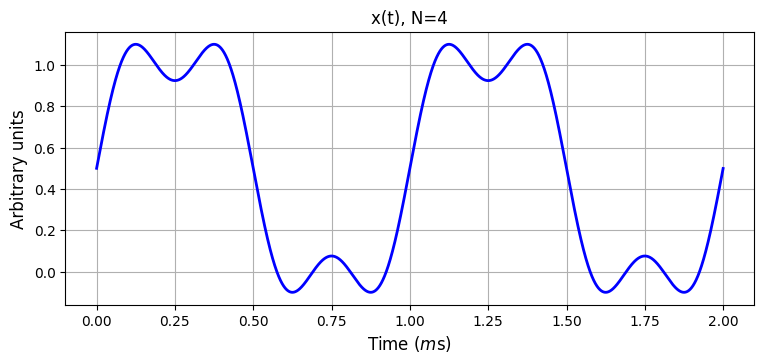

In [2]:
import sympy as sy
from sympy import *
from sympy.abc import x
import numpy as np
import matplotlib.pyplot as plt
init_printing(use_unicode=False, wrap_line=False, no_global=True)
t = symbols("t", positive=True)
To, duty,n = symbols(" To,duty,n ", positive=True)
def x(t):
    return pulse(t,.5,To)
def pulse(x,duty,To):
    return Piecewise((0, x>=duty*To),(1,x>=0),(0,x<0))
def saw(x,duty,To):
    return Piecewise((0, x>=To),(x,x>=0),(0,x<0))
a0=integrate(x(t),(t,0,To))/To
print("a0={}".format(a0))
an=integrate(x(t)*cos(2*pi/To*t*n),(t,0,To))*2/To
bn=integrate(x(t)*sin(2*pi/To*t*n),(t,0,To))*2/To
print("an={}".format(an))
print("bn={}".format(bn))
freq=1e3
ts=1/1e3
#tunit='$\mu$'
#tunit='$m$'
print("The an constants are:")
function=a0
N=4
for i in range(1,N):
    ai=an.subs(n,i).subs(To,1/freq).subs(pi,3.14)
    if abs(ai)>0:
        print("a{}=".format(i),ai)
        function=function+ai*cos(2*pi*i*freq*t)
print("The bn constants are:")
for i in range(1,N):
    bi=bn.subs(n,i).subs(To,1/freq).subs(pi,3.14)
    if abs(bi)>0:
        print("b{}=".format(i),bi)
        function=function+bi*sin(2*pi*i*freq*t)
print("function=",function)
evalfunc = lambdify((t), function, modules=['numpy'])
t = np.arange(0, 2/freq, 1/freq/10000.0)
fig, (ax2) = plt.subplots(1,figsize=(8,4))
[line3] = ax2.plot(t/ts, evalfunc(t), linewidth=2, color='blue')
ax2.set_xlabel('Time ({}s)'.format(tunit),fontsize=12)
ax2.set_ylabel('Arbitrary units',fontsize=12)
ax2.set_title('x(t), N={}'.format(N))
ax2.grid()
plt.tight_layout(pad=2, w_pad=2, h_pad=2.0)
plt.show()

This is where the student id FFT starts.

In [2]:
import random
def freq():
    x=random.randint(2,10)
    return x
def VPP():
    x=random.randint(2,3)
    return x
def Duty():
   t=random.randint(1,2)
   if t==1:
       x=random.randint(2,4)
   if t==2:
       x=random.randint(6,9)
   return x*10
SID='018457777'
A=int(SID)
random.seed(A)
print("The frequency of your pulse is {}kHz.".format(freq()))
print("The Vpp of your pulse is {}V.".format(VPP()))
print("THe duty cycle of your pulse is {}%.".format(Duty()))

The frequency of your pulse is 4kHz.
The Vpp of your pulse is 2V.
THe duty cycle of your pulse is 20%.


a0=0.400000000000000
an=2*sin(0.4*pi*n)/(pi*n)
bn=(-2*To*cos(0.4*pi*n)/(pi*n) + 2*To/(pi*n))/To
The an constants are:
a1= 0.605642968475459
a2= 0.187520879607578
a3= -0.124466666490452
a4= -0.151567018919695
a6= 0.100940494745910
The bn constants are:
b1= 0.439730692320367
b2= 0.575881346264111
b3= 0.384318233996603
b4= 0.110415212106831
b6= 0.0732884487200612
function= 0.439730692320367*sin(8000*pi*t) + 0.575881346264111*sin(16000*pi*t) + 0.384318233996603*sin(24000*pi*t) + 0.110415212106831*sin(32000*pi*t) + 0.0732884487200612*sin(48000*pi*t) + 0.605642968475459*cos(8000*pi*t) + 0.187520879607578*cos(16000*pi*t) - 0.124466666490452*cos(24000*pi*t) - 0.151567018919695*cos(32000*pi*t) + 0.10094049474591*cos(48000*pi*t) + 0.4


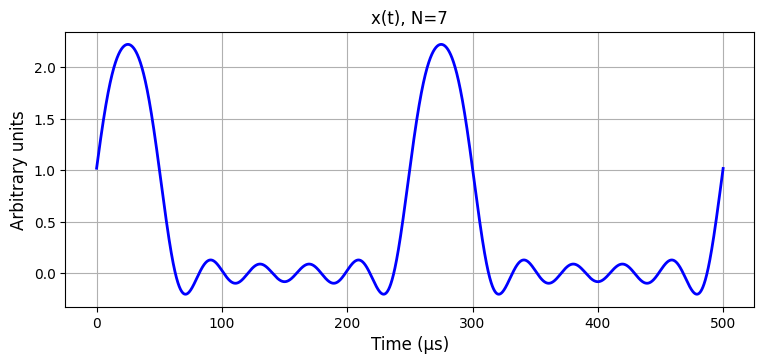

In [16]:
import sympy as sy
from sympy import *
from sympy.abc import x
import numpy as np
import matplotlib.pyplot as plt
init_printing(use_unicode=False, wrap_line=False, no_global=True)
t = symbols("t", positive=True)
To, duty,n = symbols(" To,duty,n ", positive=True)
def x(t):
    return 2*pulse(t,.2,To) #changed line for 2Vpp, 20% duty
def pulse(x,duty,To):
    return Piecewise((0, x>=duty*To),(1,x>=0),(0,x<0))
def saw(x,duty,To):
    return Piecewise((0, x>=To),(x,x>=0),(0,x<0))
a0=integrate(x(t),(t,0,To))/To
print("a0={}".format(a0))
an=integrate(x(t)*cos(2*pi/To*t*n),(t,0,To))*2/To
bn=integrate(x(t)*sin(2*pi/To*t*n),(t,0,To))*2/To
print("an={}".format(an))
print("bn={}".format(bn))
freq=4e3  #changed for 4kHz
ts=1/1e-6 # changed for microseconds
tunit='µ'
print("The an constants are:")
function=a0
N=7
for i in range(1,N):
    ai=an.subs(n,i).subs(To,1/freq).subs(pi,3.14)
    if abs(ai)>0:
        print("a{}=".format(i),ai)
        function=function+ai*cos(2*pi*i*freq*t)
print("The bn constants are:")
for i in range(1,N):
    bi=bn.subs(n,i).subs(To,1/freq).subs(pi,3.14)
    if abs(bi)>0:
        print("b{}=".format(i),bi)
        function=function+bi*sin(2*pi*i*freq*t)
print("function=",function)
evalfunc = lambdify((t), function, modules=['numpy'])
t = np.arange(0, 2/freq, 1/freq/10000.0)
fig, (ax2) = plt.subplots(1,figsize=(8,4))
[line3] = ax2.plot(t*1e6, evalfunc(t), linewidth=2, color='blue') #changed for micro seconds
ax2.set_xlabel('Time ({}s)'.format(tunit),fontsize=12)
ax2.set_ylabel('Arbitrary units',fontsize=12)
ax2.set_title('x(t), N={}'.format(N))
ax2.grid()
plt.tight_layout(pad=2, w_pad=2, h_pad=2.0)
plt.show()


the above is ready for ADLAM, copy last line of output to math